# Nettoyage des données

## Import des bibliothèques

In [1]:
import pandas as pd
import os
import glob
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

## Import du dataset

In [2]:
repertoire_data_processed = Path.cwd().parent.parent / "data" / "processed"

try:
    path_dataset = next(repertoire_data_processed.glob("01_dataset_bronze.csv"))
    print(f"Fichier trouvé : {path_dataset}")
    
    # Lecture
    df = pd.read_csv(path_dataset)
except StopIteration:
    print("Erreur : Le fichier '01_dataset_bronze.csv' est introuvable dans le dossier.")

Fichier trouvé : /home/julien/Repos/fil_rouge-etude_chomage_france/data/processed/01_dataset_bronze.csv


In [3]:
df

,date,annee,trimestre,mois,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,...,ipc,isj,ipc_energie_only,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel,pib,ict,nb_defaillances_entreprise,nb_interimaires
0,1990-01-01,1990,1,1,8.1,6.3,10.3,16.9,6.9,5.1,...,NaN,NaN,NaN,115.7,NaN,1.0,388956.0,NaN,3998.0,NaN
1,1990-02-01,1990,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,113.5,NaN,0.9,NaN,NaN,3815.0,NaN
2,1990-03-01,1990,1,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,111.5,NaN,0.9,NaN,NaN,4304.0,NaN
3,1990-04-01,1990,2,4,8.0,6.3,10.2,16.8,6.8,5.1,...,NaN,NaN,NaN,110.9,NaN,0.7,391046.0,NaN,3506.0,NaN
4,1990-05-01,1990,2,5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,110.7,NaN,0.9,NaN,NaN,3744.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,2025-11-01,2025,4,11,NaN,NaN,NaN,NaN,NaN,NaN,...,0.9,1.0,-4.6,97.7,96.4,-0.3,NaN,NaN,NaN,NaN
433,2025-12-01,2025,4,12,NaN,NaN,NaN,NaN,NaN,NaN,...,0.8,NaN,-6.8,98.7,94.5,0.1,NaN,NaN,NaN,NaN
434,2026-01-01,2026,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
435,2026-02-01,2026,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Colonnes présentes

In [4]:
df.columns

Index(['date', 'annee', 'trimestre', 'mois', 'taux_chomage_total_insee',
       'taux_chomage_homme_insee', 'taux_chomage_femme_insee',
       'taux_chomage_15_24_insee', 'taux_chomage_25_49_insee',
       'taux_chomage_50_plus_insee', 'demandeur_total_abcd_total',
       'demandeur_homme_abcd_total', 'demandeur_femme_abcd_total',
       'demandeur_total_abcd_moins25', 'demandeur_total_abcd_2549',
       'demandeur_total_abcd_plus50', 'demandeur_homme_abcd_moins25',
       'demandeur_homme_abcd_2549', 'demandeur_homme_abcd_plus50',
       'demandeur_femme_abcd_moins25', 'demandeur_femme_abcd_2549',
       'demandeur_femme_abcd_plus50', 'nb_offres_france_travail',
       'population_active', 'taux_chomage_insee', 'taux_chomage_ocde',
       'taux_euribor_3m', 'mro', 'ipc', 'isj', 'ipc_energie_only',
       'indicateur_climat_affaires', 'indicateur_climat_emploi',
       'indicateur_retournement_conjoncturel', 'pib', 'ict',
       'nb_defaillances_entreprise', 'nb_interimaires'],
      d

## Type de données

In [5]:
df.dtypes

date                                        str
annee                                     int64
trimestre                                 int64
mois                                      int64
taux_chomage_total_insee                float64
taux_chomage_homme_insee                float64
taux_chomage_femme_insee                float64
taux_chomage_15_24_insee                float64
taux_chomage_25_49_insee                float64
taux_chomage_50_plus_insee              float64
demandeur_total_abcd_total              float64
demandeur_homme_abcd_total              float64
demandeur_femme_abcd_total              float64
demandeur_total_abcd_moins25            float64
demandeur_total_abcd_2549               float64
demandeur_total_abcd_plus50             float64
demandeur_homme_abcd_moins25            float64
demandeur_homme_abcd_2549               float64
demandeur_homme_abcd_plus50             float64
demandeur_femme_abcd_moins25            float64
demandeur_femme_abcd_2549               

Commentaires : 
- Toutes les variables sont au format Float
- à noter que "dteday" est défini comme un objet. On peut le transformer en un timestamp

### Conversion de la colonne date au format datetime

In [6]:
df['date'] = pd.to_datetime(df['date'])

### Description du dataset

In [7]:
df.describe()

,date,annee,trimestre,mois,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,...,ipc,isj,ipc_energie_only,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel,pib,ict,nb_defaillances_entreprise,nb_interimaires
count,437,437.000000,437.000000,437.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,...,422.000000,421.000000,422.000000,434.000000,422.000000,434.000000,145.000000,113.000000,432.000000,103.000000
mean,2008-01-15 22:27:44.073226,2007.588101,2.482838,6.443936,8.975342,8.468493,9.573973,21.575342,8.093836,5.752055,...,1.685308,1.478860,3.230095,100.092857,100.009479,0.182811,529179.234483,85.636283,4471.835648,661273.427517
min,1990-01-01 00:00:00,1990.000000,1.000000,1.000000,7.100000,6.300000,6.800000,16.500000,6.300000,4.100000,...,-0.700000,-0.100000,-18.300000,45.700000,42.000000,-1.000000,388956.000000,60.300000,703.000000,477838.210451
25%,1999-01-01 00:00:00,1999.000000,1.000000,3.000000,8.000000,7.600000,8.700000,19.025000,7.200000,5.100000,...,0.900000,0.700000,-1.500000,94.625000,94.000000,-0.700000,459345.000000,74.100000,3964.250000,593762.607550
50%,2008-01-01 00:00:00,2008.000000,2.000000,6.000000,9.000000,8.400000,9.600000,21.850000,8.100000,5.750000,...,1.600000,1.200000,2.050000,101.250000,100.950000,0.700000,546199.000000,88.200000,4684.500000,640411.444797
75%,2017-02-01 00:00:00,2017.000000,3.000000,9.000000,10.075000,9.275000,10.300000,23.800000,9.100000,6.400000,...,2.100000,1.700000,7.875000,107.100000,107.200000,0.900000,590306.000000,96.400000,5369.750000,730857.542042
max,2026-03-01 00:00:00,2026.000000,4.000000,12.000000,10.700000,11.000000,12.100000,27.900000,9.800000,7.200000,...,6.300000,6.100000,33.100000,121.000000,120.000000,1.000000,661062.000000,112.800000,6897.000000,821378.102512
std,NaN,10.469249,1.124295,3.476618,1.082370,1.169129,1.409429,2.983438,1.031117,0.741408,...,1.188293,1.127093,7.499034,9.920619,9.977588,0.819373,81043.124941,14.409341,1240.152331,89845.599252


Commentaire : ATTENTION aux variables d'indices !!!

- indicateur_retournement_conjoncturel
- ipc_energie_only
- ipc
- isj

à recalculer en premier lieu !

# Valeurs manquantes

## La problématique

Nous avons de nombreuses sources de données, chacune présentant des périodes et des fréquences de mises à jour différentes.

| Titre (Variable) | Fréquence | Date début | Date fin |
| :--- | :--- | :--- | :--- |
| Taux de chômage total INSEE (`taux_chomage_total_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage Homme INSEE (`taux_chomage_homme_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage Femme INSEE (`taux_chomage_femme_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage 15-24 ans INSEE (`taux_chomage_15_24_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage 25-49 ans INSEE (`taux_chomage_25_49_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage 50 ans et plus INSEE (`taux_chomage_50_plus_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| DEFM Total ABCDE (`demandeur_total_abcd_total`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes ABCDE (`demandeur_homme_abcd_total`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes ABCDE (`demandeur_femme_abcd_total`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM -25 ans ABCDE (`demandeur_total_abcd_moins25`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM 25-49 ans ABCDE (`demandeur_total_abcd_2549`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM 50 ans et plus ABCDE (`demandeur_total_abcd_plus50`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes -25 ans ABCDE (`demandeur_homme_abcd_moins25`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes 25-49 ans ABCDE (`demandeur_homme_abcd_2549`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes 50 ans+ ABCDE (`demandeur_homme_abcd_plus50`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes -25 ans ABCDE (`demandeur_femme_abcd_moins25`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes 25-49 ans ABCDE (`demandeur_femme_abcd_2549`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes 50 ans+ ABCDE (`demandeur_femme_abcd_plus50`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| Offres d'emploi France Travail (`nb_offres_france_travail`) | Mensuelle | 01/01/2015 | 30/09/2025 |
| Population active (OIT) (`population_active`) | Annuelle | 01/01/1990 | 31/12/2024 |
| Taux de chômage (INSEE) (`taux_chomage_insee`) | Annuelle | 01/01/1975 | 31/12/2024 |
| Taux de chômage (OCDE) (`taux_chomage_ocde`) | Mensuelle | 01/01/1990 | 31/10/2025 |
| Euribor 3-month (`taux_euribor_3m`) | Mensuelle | 31/01/1994 | 31/12/2025 |
| Main refinancing operations (`MRO`) | Ponctuelle | 01/01/1999 | 11/06/2025 |
| Indice des prix à la consommation (`ipc`) | Mensuelle | 01/01/1991 | 31/12/2025 |
| Inflation sous-jacente (`isj`) | Mensuelle | 01/01/1991 | 30/11/2025 |
| IPC ENERGIE (`ipc_energie_only`) | Mensuelle | 01/01/1991 | 31/12/2025 |
| Climat des affaires (`indicateur_climat_affaires`) | Mensuelle | 01/01/1977 | 31/12/2025 |
| Climat de l'emploi (`indicateur_climat_emploi`) | Mensuelle | 01/01/1991 | 31/12/2025 |
| Retournement conjoncturel (`indicateur_retournement_conjoncturel`) | Mensuelle | 01/01/1988 | 31/12/2025 |
| Produit intérieur brut total (`pib`) | Trimestrielle | 01/01/1949 | 30/09/2025 |
| Indice du coût du travail (`ict`) | Trimestrielle | 01/01/1988 | 30/09/2025 |
| Défaillances d'entreprises (`nb_defaillances_entreprise`) | Mensuelle | 31/01/1990 | 31/10/2025 |
| L'emploi intérimaire (`nb_interimaires`) | Trimestrielle | 01/01/2000 | 30/09/2025 |

Le dataset présente une granularité maximale au mois cependant de nombreuses variables sont trimestrialisées.

Pour régler ce problème, nous pourrions rester au trimestre pour les raisons suivantes :

1) Fiabilité : En restant au trimestre, nous travaillons sur des données réelles (non interpolées) ==> pas d'information "artificielle".
2) Stabilité : Les variations mensuelles du chômage ou de l'inflation peuvent être "bruitées" par des facteurs saisonniers très courts. Le trimestre lisse ce bruit
3) Cohérence : La majorité des colonnes centrales (chômage par âge/sexe, demandeurs d'emploi, PIB, ICT) sont déjà à cette fréquence, de même que notre target "taux_chomage_total_insee" 

## Désactivation de la colonne "nb_offres_france_travail"

à noter que la variable Offres d'emploi France Travail (`nb_offres_france_travail`) ne débute qu'en 2015 :

| Titre (Variable) | Fréquence | Date début | Date fin |
| :--- | :--- | :--- | :--- |
...
| Offres d'emploi France Travail (`nb_offres_france_travail`) | Mensuelle | 01/01/2015 | 30/09/2025 |
...


Nous la sortons du dataset final.

In [8]:
df = df.drop(["nb_offres_france_travail"], axis=1)

## Apercu des valeurs manquantes

In [9]:
df.isna().any()

date                                    False
annee                                   False
trimestre                               False
mois                                    False
taux_chomage_total_insee                 True
taux_chomage_homme_insee                 True
taux_chomage_femme_insee                 True
taux_chomage_15_24_insee                 True
taux_chomage_25_49_insee                 True
taux_chomage_50_plus_insee               True
demandeur_total_abcd_total               True
demandeur_homme_abcd_total               True
demandeur_femme_abcd_total               True
demandeur_total_abcd_moins25             True
demandeur_total_abcd_2549                True
demandeur_total_abcd_plus50              True
demandeur_homme_abcd_moins25             True
demandeur_homme_abcd_2549                True
demandeur_homme_abcd_plus50              True
demandeur_femme_abcd_moins25             True
demandeur_femme_abcd_2549                True
demandeur_femme_abcd_plus50       

In [10]:
df.isna().sum()

date                                      0
annee                                     0
trimestre                                 0
mois                                      0
taux_chomage_total_insee                291
taux_chomage_homme_insee                291
taux_chomage_femme_insee                291
taux_chomage_15_24_insee                291
taux_chomage_25_49_insee                291
taux_chomage_50_plus_insee              291
demandeur_total_abcd_total              317
demandeur_homme_abcd_total              317
demandeur_femme_abcd_total              317
demandeur_total_abcd_moins25            317
demandeur_total_abcd_2549               317
demandeur_total_abcd_plus50             317
demandeur_homme_abcd_moins25            317
demandeur_homme_abcd_2549               317
demandeur_homme_abcd_plus50             317
demandeur_femme_abcd_moins25            317
demandeur_femme_abcd_2549               317
demandeur_femme_abcd_plus50             317
population_active               

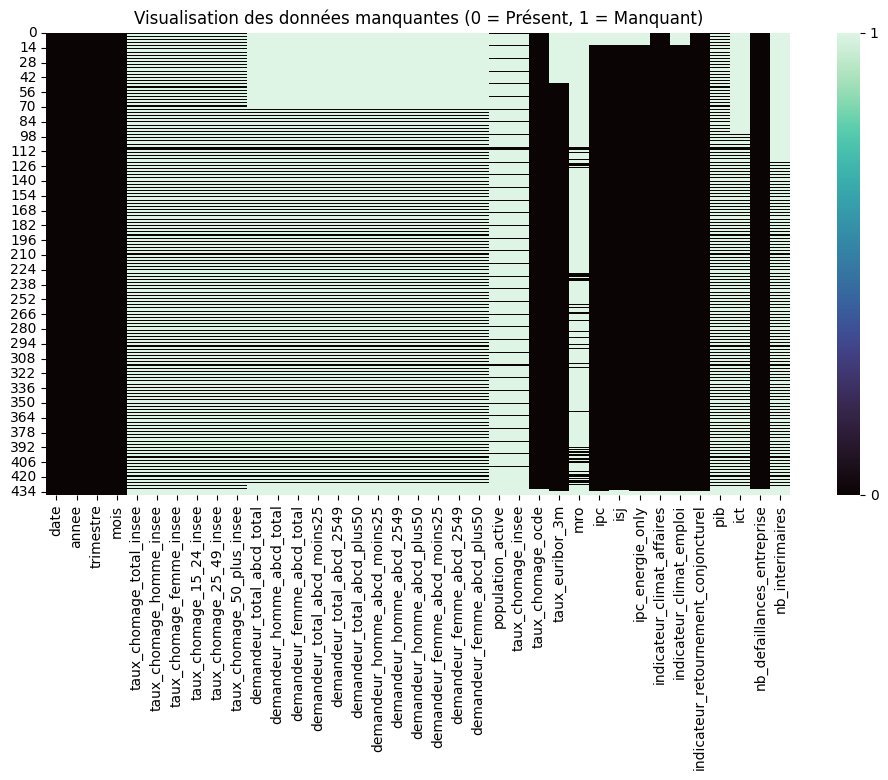

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), 
            vmin=0, 
            vmax=1, 
            cmap='mako', 
            cbar_kws={'ticks': [0, 1]})

plt.title("Visualisation des données manquantes (0 = Présent, 1 = Manquant)")
plt.show()

### Traitement de la colonne "mro"

On propage le taux directeur (ponctuel) sur les mois suivants pour qu'il soit "actif" dans le calcul de la moyenne trimestrielle

In [12]:
df['mro'] = df['mro'].ffill()

### Définition des règles d'agrégation vers le trimestriel

In [13]:
cols_trim_prev = [
    'taux_chomage_total_insee', 'taux_chomage_homme_insee', 'taux_chomage_femme_insee',
    'taux_chomage_15_24_insee', 'taux_chomage_25_49_insee', 'taux_chomage_50_plus_insee',
    'demandeur_total_abcd_total', 'demandeur_homme_abcd_total', 'demandeur_femme_abcd_total',
    'demandeur_total_abcd_moins25', 'demandeur_total_abcd_2549', 'demandeur_total_abcd_plus50',
    'demandeur_homme_abcd_moins25', 'demandeur_homme_abcd_2549', 'demandeur_homme_abcd_plus50',
    'demandeur_femme_abcd_moins25', 'demandeur_femme_abcd_2549', 'demandeur_femme_abcd_plus50',
    'population_active', 'pib', 'ict', 'nb_interimaires'
]

In [14]:
# Agrégation selon la nature de la donnée
agg_dict = {}
for col in cols_trim_prev:
    if col in df.columns: agg_dict[col] = 'first'

In [15]:
# Variables mensuelles (Moyenne)
for col in ['taux_euribor_3m', 'mro', 'ipc', 'isj', 'ipc_energie_only', 'taux_chomage_ocde']:
    if col in df.columns: agg_dict[col] = 'mean'

In [16]:
# Variables de flux (Somme)
for col in ['nb_defaillances_entreprise', 'nb_offres_france_travail']:
    if col in df.columns: agg_dict[col] = 'sum'

In [17]:
# Variables de sentiment (Dernière valeur du trimestre)
for col in ['indicateur_climat_affaires', 'indicateur_climat_emploi', 'indicateur_retournement_conjoncturel']:
    if col in df.columns: agg_dict[col] = 'last'

## Passage au format Trimestriel (Resampling)

In [18]:
# 'QS' = Quarter Start (L'index sera le 01/01, 01/04, 01/07, 01/10)
df_q = df.set_index('date').resample('QS').agg(agg_dict)

In [19]:
df_q.head(10)

,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,...,taux_euribor_3m,mro,ipc,isj,ipc_energie_only,taux_chomage_ocde,nb_defaillances_entreprise,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel
date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,8.1,6.3,10.3,16.9,6.9,5.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9.500000,12117.0,111.5,NaN,0.9
1990-04-01,8.0,6.3,10.2,16.8,6.8,5.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9.400000,11310.0,108.9,NaN,1.0
1990-07-01,8.0,6.3,10.1,16.7,6.8,5.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9.300000,9416.0,102.8,NaN,-1.0
1990-10-01,8.0,6.3,10.0,16.9,6.8,5.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9.300000,13286.0,98.8,NaN,-1.0
1991-01-01,7.9,6.3,10.0,17.0,6.8,5.2,NaN,NaN,NaN,NaN,...,NaN,NaN,3.333333,3.966667,5.233333,9.266667,14197.0,94.2,99.4,-0.9
1991-04-01,8.1,6.4,10.1,17.4,6.9,5.4,NaN,NaN,NaN,NaN,...,NaN,NaN,3.300000,3.900000,4.766667,9.433333,13286.0,93.9,91.6,-0.8
1991-07-01,8.3,6.6,10.3,17.7,7.1,5.6,NaN,NaN,NaN,NaN,...,NaN,NaN,3.200000,3.900000,1.633333,9.700000,10817.0,94.7,89.4,-0.9
1991-10-01,8.5,6.8,10.6,17.8,7.3,5.8,NaN,NaN,NaN,NaN,...,NaN,NaN,3.000000,3.800000,-2.433333,10.000000,14563.0,91.5,91.3,-1.0
1992-01-01,8.7,7.1,10.8,18.3,7.6,6.0,NaN,NaN,NaN,NaN,...,NaN,NaN,2.766667,3.533333,-1.233333,10.266667,15868.0,95.5,90.1,-1.0


# Feature Engineering

## Population active

In [20]:
# Population active : interpolation linéaire pour passer de l'année aux trimestres
df_q['population_active'] = df_q['population_active'].interpolate(method='linear')

- L'argument mathématique : Élimination de tendance. Cette série est structurellement haussière.

- L'argument métier : Pression démographique. Si la population active augmente plus vite que l'emploi, le chômage monte mécaniquement.

In [21]:
df_q['pop_active_var'] = df_q['population_active'].pct_change()

## PIB

- L'argument mathématique (Stationnarité) : Le PIB en valeur brute (ex: 600 milliards €) est une série "non-stationnaire". Elle augmente presque toujours avec le temps. Si on l'utilise brute, un modèle risque de créer une corrélation artificielle simplement parce que les deux courbes montent. En calculant le taux de variation, on rend la donnée stationnaire, ce qui est indispensable pour la plupart des algorithmes.

- L'argument métier (Loi d'Okun) : Ce n'est pas la richesse totale d'un pays qui crée de l'emploi, c'est sa croissance. En économie, on observe qu'il faut un certain niveau de croissance trimestrielle pour stabiliser ou réduire le chômage.

In [22]:
# Croissance du PIB (Trimestre sur Trimestre)
df_q['pib_qoq'] = df_q['pib'].pct_change()

In [23]:
# Croissance du PIB en Log-différence. La transformation Δln(PIB) est la norme pour obtenir un taux de croissance stationnaire.
df_q['pib_logdiff'] = np.log(df_q['pib']).diff()

## Inflation : passage en glissement annuel
- L'argument mathématique (Saisonnalité) : Les prix varient selon les mois (soldes, énergie en hiver). En comparant l'indice T par rapport à T−4 (même trimestre de l'année précédente), on élimine naturellement ces effets saisonniers sans avoir besoin de calculs complexes.

- L'argument métier : C'est la mesure standard de l'inflation. Elle reflète le pouvoir d'achat réel. Une inflation trop forte peut freiner la consommation et donc augmenter le chômage à terme.

In [24]:
# Inflation réelle (Glissement annuel - comparaison avec T-4)
df_q['ipc_yoy'] = df_q['ipc'].pct_change(periods=4)

# Inflation de l'énergie (Glissement annuel - comparaison avec T-4)
df_q['ipc_energie_only_yoy'] = df_q['ipc_energie_only'].pct_change(periods=4)

## Évolution du coût du travail (ICT) et des salaires (ISJ)

- L'argument mathématique : Accélération relative. On mesure la vitesse de croissance du coût salarial.

- L'argument métier : Pouvoir d'achat vs Marges. Une hausse trop forte sans productivité dégrade l'emploi.

In [25]:
# ISJ - Indice de Salaire Journalier
df_q['isj_var'] = df_q['isj'].pct_change()

In [26]:
# ICT - Indice du Coût du Travail
df_q['ict_var'] = df_q['ict'].pct_change()

## Taux de Chômage : passage en différence première

- L'argument mathématique (Autocorrélation) : Le taux de chômage est très "inerte". S'il est de 7,5% ce trimestre, il y a 99% de chances qu'il soit proche de 7,5% le mois prochain. Prédire la valeur brute est trop facile et n'apporte rien. Un taux est une proportion ; on étudie sa variation en points yt​−yt−1​.

- L'argument métier : C'est l'indicateur central de santé sociale du pays. Ce qui intéresse le décideur, c'est de savoir si le chômage accélère, stagne ou recule. En prédisant la variation (Δ), on se concentre sur les points d'inflexion de l'économie.

In [27]:
# Variation du chômage INSEE (Cible : combien de points on gagne ou perd ce trimestre)
df_q['taux_chomage_total_insee_diff'] = df_q['taux_chomage_total_insee'].diff()

In [28]:
# Variation du chômage OCDE
df_q['taux_chomage_ocde_diff'] = df_q['taux_chomage_ocde'].diff()

## Indices de Climat : standardisation

- L'argument mathématique (Mise à l'échelle) : Les indices de climat sont souvent basés sur 100, tandis que les taux d'intérêt sont entre 0 et 4. Si on les met ensemble dans un modèle sans transformation, le modèle donnera plus de poids aux variables ayant les plus gros chiffres (l'indice 100).

- L'argument métier : Le Z-score permet de répondre à la question : "La confiance des patrons est-elle exceptionnellement basse par rapport à l'histoire ?". Un score de -2 signifie que nous sommes dans une crise majeure (comme 2008 ou Covid), peu importe l'unité de mesure originale.

In [29]:
# Standardisation (Z-Score) du climat des affaires
# Permet de voir si on est historiquement au dessus ou en dessous de la normale
for col in ['indicateur_climat_affaires', 'indicateur_climat_emploi']:
    df_q[f'{col}_zscore'] = (df_q[col] - df_q[col].mean()) / df_q[col].std()

## Climat des affaires :
- L'argument mathématique (Causalité temporelle) : Dans une série temporelle, la cause (X) précède souvent l'effet (Y). Si on utilise les variables du même trimestre, on fait de la corrélation. Si on utilise X au trimestre précédent pour prédire Y aujourd'hui, on fait de la prédiction.

- L'argument métier (Délai de décision) : Un chef d'entreprise qui perd confiance (baisse du climat des affaires) ne licencie pas le jour même. Il y a un temps de latence administratif et social. Intégrer un lag permet au modèle de capter ce délai de réaction.

In [30]:
df_q['indicateur_climat_affaires_diff'] = df_q['indicateur_climat_affaires'].diff()

#### ## Climat des affaires : variable décalé (lag)

In [31]:
# Création de "Lags" (Variables décalées)
# Très important : le climat des affaires d'aujourd'hui prédit souvent le chômage de demain
df_q['indicateur_climat_affaires_lag'] = df_q['indicateur_climat_affaires'].shift(1)

## Taux Euribor 3M

- L'argument mathématique : Capture de choc. Les taux sont persistants, seule leur variation brusque impacte les modèles.

- L'argument métier : Coût du crédit. Une hausse renchérit le financement court terme des entreprises.

In [32]:
df_q['taux_euribor_3m_diff'] = df_q['taux_euribor_3m'].diff()

## MRO

- L'argument mathématique : Différence discrète. C'est une fonction en escalier ; la différence isole les dates de pivot monétaire.

- L'argument métier : Signal de la BCE. Une hausse du MRO est un frein volontaire mis sur l'économie pour freiner l'inflation.

In [33]:
df_q['mro_diff'] = df_q['mro'].diff()

## Nombre d'intérimaires

- L'argument mathématique : Stationnarisation. L'intérim est très volatil, le pct_change capture les cycles courts.

- L'argument métier : Le "Canari dans la mine". C'est la première variable qui baisse avant une crise et la première qui monte lors d'une reprise.

In [34]:
df_q['nb_interimaires_var'] = df_q['nb_interimaires'].pct_change()

## Nombre de défaillance d'entreprise

- L'argument mathématique : Vitesse de dégradation. On observe le taux de croissance des faillites.

- L'argument métier : Destruction d'emplois. Les faillites sont des licenciements économiques immédiats.

In [35]:
df_q['nb_defaillances_entreprise_var'] = df_q['nb_defaillances_entreprise'].pct_change()

# Filtrage des données

## Ajustement des périodes

Afin d'harmoniser les périodes de toutes les colonnes

In [36]:
# Filtrage de la période  : 1er Janvier 2000 au 2ème trimestre 2025
df_q = df_q.loc['2000-01-01':'2025-07-01']

### Nouveau résumé des valeurs manquantes

In [37]:
df_q.isna().sum()

taux_chomage_total_insee                0
taux_chomage_homme_insee                0
taux_chomage_femme_insee                0
taux_chomage_15_24_insee                0
taux_chomage_25_49_insee                0
taux_chomage_50_plus_insee              0
demandeur_total_abcd_total              1
demandeur_homme_abcd_total              1
demandeur_femme_abcd_total              1
demandeur_total_abcd_moins25            1
demandeur_total_abcd_2549               1
demandeur_total_abcd_plus50             1
demandeur_homme_abcd_moins25            1
demandeur_homme_abcd_2549               1
demandeur_homme_abcd_plus50             1
demandeur_femme_abcd_moins25            1
demandeur_femme_abcd_2549               1
demandeur_femme_abcd_plus50             1
population_active                       0
pib                                     0
ict                                     0
nb_interimaires                         0
taux_euribor_3m                         0
mro                               

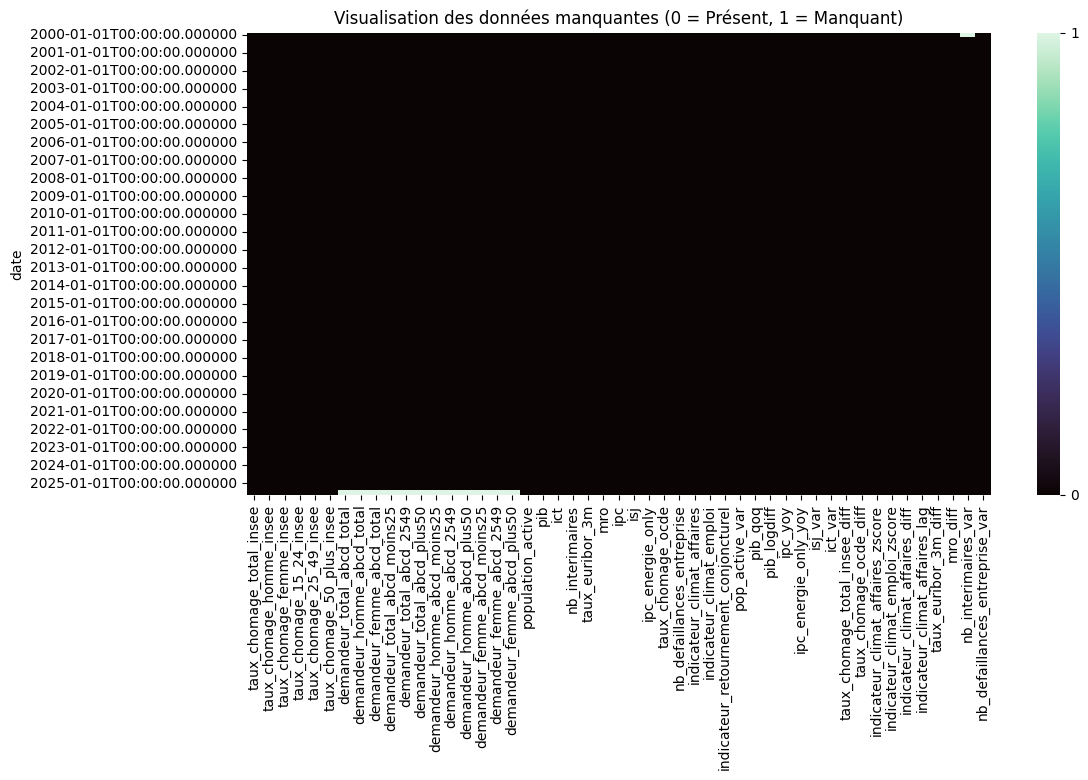

In [38]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_q.isna(), 
            vmin=0, 
            vmax=1, 
            cmap='mako', 
            cbar_kws={'ticks': [0, 1]})

plt.title("Visualisation des données manquantes (0 = Présent, 1 = Manquant)")
plt.show()

#### Ajustement des dernières valeurs manquantes

In [39]:
df_q = df_q.bfill()
df_q = df_q.ffill()

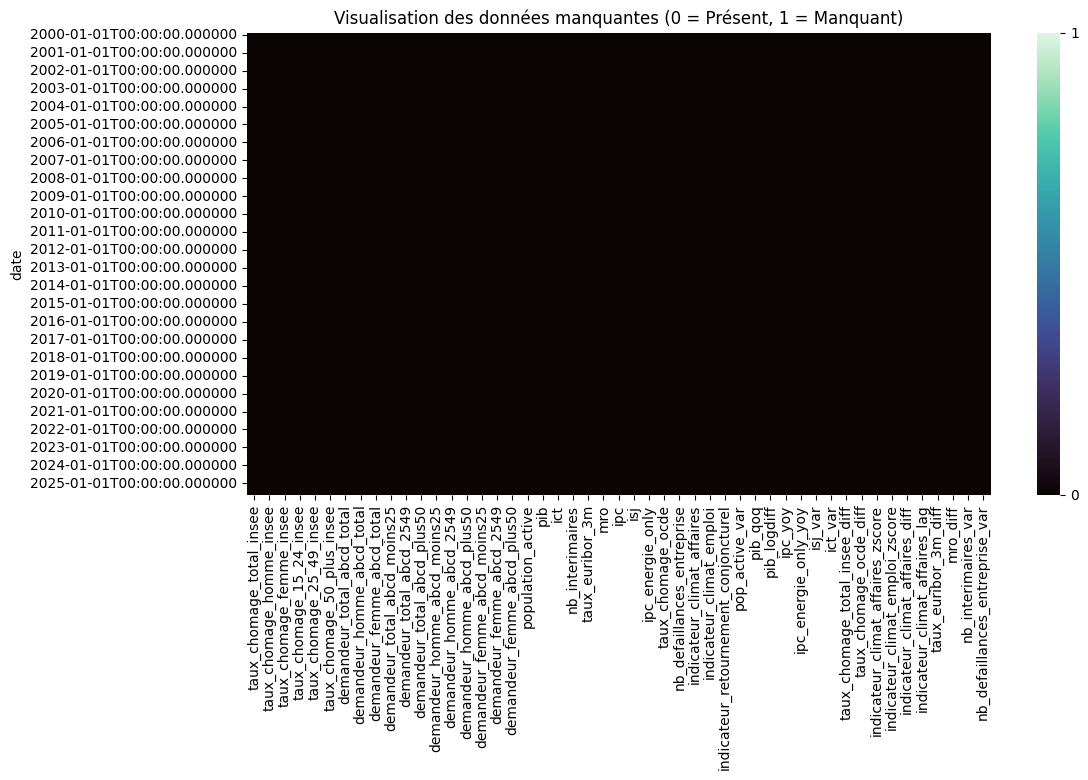

In [40]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_q.isna(), 
            vmin=0, 
            vmax=1, 
            cmap='mako', 
            cbar_kws={'ticks': [0, 1]})

plt.title("Visualisation des données manquantes (0 = Présent, 1 = Manquant)")
plt.show()

#### Dernière vérification des valeurs manquantes

In [41]:
print(df_q.isna().sum())

taux_chomage_total_insee                0
taux_chomage_homme_insee                0
taux_chomage_femme_insee                0
taux_chomage_15_24_insee                0
taux_chomage_25_49_insee                0
taux_chomage_50_plus_insee              0
demandeur_total_abcd_total              0
demandeur_homme_abcd_total              0
demandeur_femme_abcd_total              0
demandeur_total_abcd_moins25            0
demandeur_total_abcd_2549               0
demandeur_total_abcd_plus50             0
demandeur_homme_abcd_moins25            0
demandeur_homme_abcd_2549               0
demandeur_homme_abcd_plus50             0
demandeur_femme_abcd_moins25            0
demandeur_femme_abcd_2549               0
demandeur_femme_abcd_plus50             0
population_active                       0
pib                                     0
ict                                     0
nb_interimaires                         0
taux_euribor_3m                         0
mro                               

# Visualisation du dataframe final

In [42]:
df_q.head(10)

,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,...,taux_chomage_total_insee_diff,taux_chomage_ocde_diff,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_climat_affaires_diff,indicateur_climat_affaires_lag,taux_euribor_3m_diff,mro_diff,nb_interimaires_var,nb_defaillances_entreprise_var
date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,9.1,8.0,10.3,19.0,8.4,6.1,4018600.0,1774200.0,2244400.0,690800.0,...,-0.4,-0.433333,1.723014,1.345448,-4.3,121.0,0.112500,0.416667,0.046137,-0.007076
2000-04-01,8.7,7.6,9.9,18.0,8.0,5.8,3890000.0,1701100.0,2188900.0,654800.0,...,-0.4,-0.533333,1.754474,1.977185,0.3,116.7,0.720700,0.666667,0.046137,-0.141156
2000-07-01,8.4,7.2,9.6,17.4,7.8,5.5,3807900.0,1659300.0,2148600.0,632600.0,...,-0.3,-0.433333,1.901287,1.861366,1.4,117.0,0.474600,0.333333,0.016013,-0.148986
2000-10-01,8.0,6.9,9.4,16.9,7.5,5.2,3690300.0,1601400.0,2088900.0,604600.0,...,-0.4,-0.366667,1.492307,1.966656,-3.9,118.4,0.286567,0.000000,-0.021358,0.328532
2001-01-01,7.8,6.6,9.2,16.8,7.3,4.9,3609400.0,1565300.0,2044100.0,588000.0,...,-0.2,-0.200000,1.376954,1.819251,-1.1,114.5,-0.279133,0.000000,0.039423,-0.244370
2001-04-01,7.7,6.5,9.1,16.7,7.2,4.9,3581100.0,1558900.0,2022200.0,586200.0,...,-0.1,0.033333,0.422670,1.061167,-9.1,113.4,-0.154267,0.000000,-0.046257,0.356181
2001-07-01,7.7,6.7,8.9,17.0,7.2,4.9,3592500.0,1578300.0,2014200.0,597800.0,...,0.0,0.066667,-0.154095,0.724241,-5.5,104.3,-0.322933,0.000000,-0.024610,-0.241800
2001-10-01,7.8,6.9,8.8,17.3,7.2,4.8,3658600.0,1627700.0,2030900.0,620900.0,...,0.1,0.000000,-0.489668,0.334670,-3.2,98.8,-0.824333,0.000000,-0.052172,0.354551
2002-01-01,7.8,7.1,8.7,17.5,7.2,4.9,3693700.0,1663200.0,2030500.0,630400.0,...,0.0,-0.033333,-0.017769,0.134620,4.5,95.6,-0.081267,0.000000,0.031686,-0.111816


In [43]:
df_q.tail(10)

,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,...,taux_chomage_total_insee_diff,taux_chomage_ocde_diff,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_climat_affaires_diff,indicateur_climat_affaires_lag,taux_euribor_3m_diff,mro_diff,nb_interimaires_var,nb_defaillances_entreprise_var
date,,,,,,,,,,,,,,,,,,,,,
2023-04-01,7.2,7.4,7.1,17.1,6.6,5.1,5348000.0,2580200.0,2767800.0,667100.0,...,0.1,0.200000,0.055637,0.682125,-2.2,103.0,0.724500,0.750000,-0.008781,-0.072138
2023-07-01,7.4,7.3,7.4,17.4,6.7,5.1,5364800.0,2592700.0,2772100.0,678000.0,...,0.2,0.100000,-0.038742,0.418901,-0.9,100.8,0.420933,0.500000,-0.024347,-0.142942
2023-10-01,7.5,7.6,7.4,17.6,7.0,5.0,5395100.0,2616000.0,2779100.0,690200.0,...,0.1,0.166667,-0.143609,0.092504,-1.0,99.9,0.180067,0.250000,-0.009370,0.423587
2024-01-01,7.5,7.7,7.3,18.1,6.8,5.1,5392100.0,2619700.0,2772400.0,689100.0,...,0.0,-0.100000,0.013691,0.081975,1.5,98.9,-0.033800,0.000000,-0.006177,0.070136
2024-04-01,7.3,7.3,7.4,18.0,6.6,5.0,5389800.0,2623000.0,2766800.0,688700.0,...,-0.2,-0.100000,-0.070202,-0.002256,-0.8,100.4,-0.115433,-0.083333,-0.026257,-0.070685
2024-07-01,7.4,7.6,7.1,19.7,6.6,4.7,5412400.0,2637700.0,2774700.0,692700.0,...,0.1,0.033333,-0.300908,-0.160190,-2.2,99.6,-0.252833,-0.366667,-0.011181,-0.162955
2024-10-01,7.3,7.4,7.1,18.7,6.6,4.7,5491700.0,2678900.0,2812800.0,716800.0,...,-0.1,-0.100000,-0.552588,-0.381298,-2.4,97.4,-0.558867,-0.733333,-0.017005,0.337962
2025-01-01,7.5,7.5,7.4,19.2,6.8,4.8,5738000.0,2811000.0,2927000.0,866800.0,...,0.2,0.166667,-0.384802,-0.391827,1.6,95.0,-0.439667,-0.416667,-0.004978,-0.013529
2025-04-01,7.6,7.7,7.4,19.1,6.9,4.8,5612100.0,2749800.0,2862300.0,792800.0,...,0.1,0.100000,-0.447721,-0.191777,-0.6,96.6,-0.449133,-0.583333,-0.000738,-0.047422


# Export du dataset au format CSV (SILVER)

In [44]:
repertoire_data_processed = Path.cwd().parent.parent / "data" / "processed"
chemin_export = repertoire_data_processed / "02_dataset_silver.csv"

df_q.to_csv(chemin_export, index=True, encoding='utf-8')

# Export du dataset au format CSV (GOLD)

# BONUS : graphs

Corrélation calculée : 0.5244


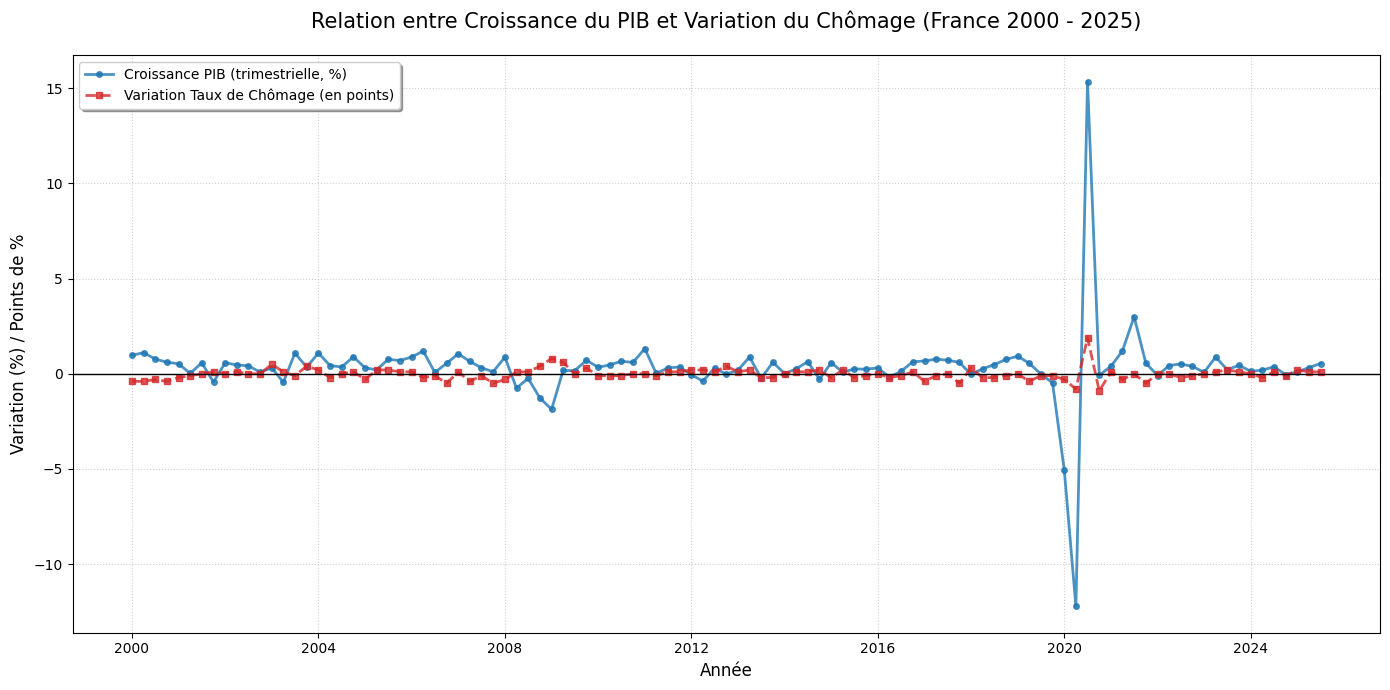

In [45]:
# 1. Préparation des données (on utilise le dataset df_q généré précédemment)
# Conversion de la croissance du PIB en pourcentage pour la lisibilité
pib_growth_pct = df_q['pib_qoq'] * 100
var_chomage = df_q['taux_chomage_total_insee_diff']

# 2. Création du graphique
plt.figure(figsize=(14, 7))

# Tracé de la croissance du PIB
plt.plot(df_q.index, pib_growth_pct, label='Croissance PIB (trimestrielle, %)', 
         color='#1f77b4', linewidth=2, marker='o', markersize=4, alpha=0.8)

# Tracé de la variation du chômage
plt.plot(df_q.index, var_chomage, label='Variation Taux de Chômage (en points)', 
         color='#d62728', linestyle='--', linewidth=2, marker='s', markersize=4, alpha=0.8)

# Ajout d'une ligne horizontale à 0 (équilibre)
plt.axhline(0, color='black', linewidth=1, linestyle='-')

# 3. Personnalisation esthétique
plt.title('Relation entre Croissance du PIB et Variation du Chômage (France 2000 - 2025)', fontsize=15, pad=20)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Variation (%) / Points de %', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle=':', alpha=0.6)

# Optimisation de l'espace
plt.tight_layout()

# 4. Sauvegarde
plt.savefig('correlation_pib_chomage.png', dpi=300)

# Affichage de la corrélation calculée
correlation = pib_growth_pct.corr(var_chomage)
print(f"Corrélation calculée : {correlation:.4f}")

Analyse du graphique :

    Loi d'Okun inversée par les crises : En temps normal, une forte croissance (PIB > 0) entraîne une baisse du chômage (Variation < 0).

    Le choc COVID (2020-2021) : On observe des mouvements extrêmes. La chute brutale du PIB en 2020 n'a pas provoqué une explosion immédiate du chômage grâce aux mesures de chômage partiel. À l'inverse, le "rebond" technique de 2021 montre une corrélation positive atypique (0.53 sur l'ensemble de la période), car les indicateurs de chômage ont repris leurs niveaux normaux en même temps que l'activité.

    Signaux récents (2024-2025) : Les deux courbes se stabilisent autour de zéro, illustrant une phase de croissance molle et un chômage qui stagne ou remonte légèrement.